<a href="https://colab.research.google.com/github/rasikajagatap177-droid/Data-Science-Journey/blob/main/Multiple%20LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

create dataset


In [2]:
data = {
    "size": [700, 900, 1000, 1000, 1200, 1500, 1500, 1700, 1800, 1800, 2000, 2200],
    "bhk": [1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4],
    "price": [1800000, 2200000, 2500000, 2800000, 3200000, 3800000,
              4000000, 4500000, 4800000, 5000000, 5500000, 6000000]
}

print(data)

{'size': [700, 900, 1000, 1000, 1200, 1500, 1500, 1700, 1800, 1800, 2000, 2200], 'bhk': [1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4], 'price': [1800000, 2200000, 2500000, 2800000, 3200000, 3800000, 4000000, 4500000, 4800000, 5000000, 5500000, 6000000]}


In [3]:
print(data)

{'size': [700, 900, 1000, 1000, 1200, 1500, 1500, 1700, 1800, 1800, 2000, 2200], 'bhk': [1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4], 'price': [1800000, 2200000, 2500000, 2800000, 3200000, 3800000, 4000000, 4500000, 4800000, 5000000, 5500000, 6000000]}


In [7]:
df = pd.DataFrame(data)

print(df)

    size  bhk    price
0    700    1  1800000
1    900    1  2200000
2   1000    1  2500000
3   1000    2  2800000
4   1200    2  3200000
5   1500    2  3800000
6   1500    3  4000000
7   1700    3  4500000
8   1800    3  4800000
9   1800    4  5000000
10  2000    4  5500000
11  2200    4  6000000


In [8]:
df.corr()

,size,bhk,price
size,1.000000,0.937254,0.996373
bhk,0.937254,1.000000,0.960146
price,0.996373,0.960146,1.000000


visuvalizing using seaborn

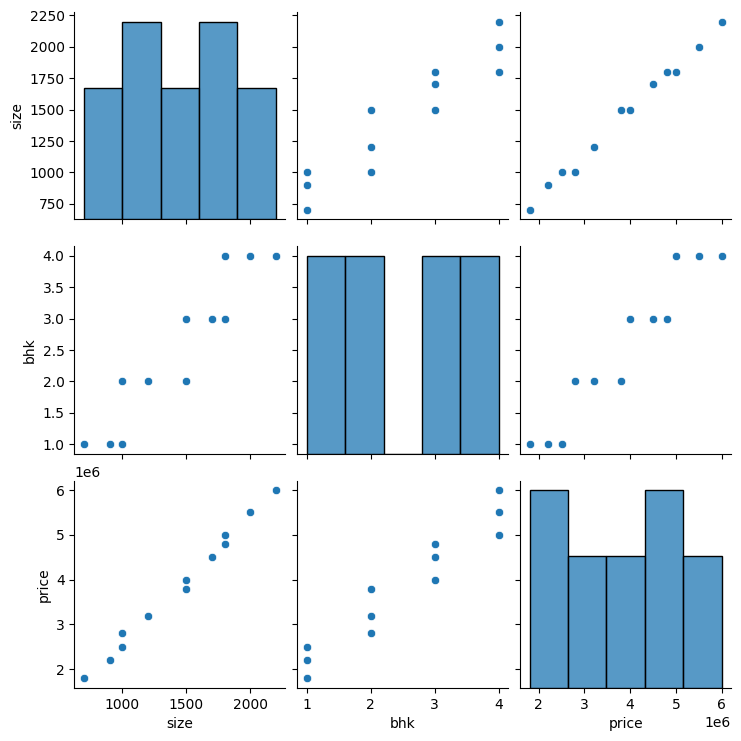

In [9]:
sns.pairplot(df)

dependent and independent features

In [10]:
X=df[["size","bhk"]]


In [11]:
y=df["price"]

In [18]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:")
print(X_train)

print("Testing data:")
print(X_test)

Training data:
    size  bhk
8   1800    3
5   1500    2
2   1000    1
1    900    1
11  2200    4
4   1200    2
7   1700    3
3   1000    2
6   1500    3
Testing data:
    size  bhk
10  2000    4
9   1800    4
0    700    1


Model training

In [13]:
model=LinearRegression()

In [14]:
model.fit(X_train,y_train)

LinearRegression()

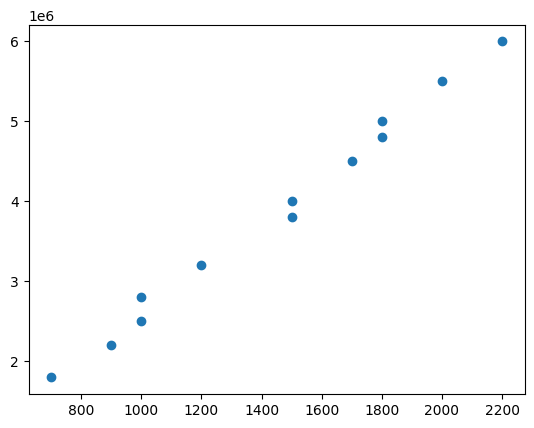

In [15]:
plt.scatter(df["size"],df["price"])

view model parameter

In [19]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: -31789.848619768396
Coefficients: [  2229.74176313 264381.12199466]


make predictions

In [20]:
y_pred=model.predict(X_test)
print("predicted=",y_pred)
print("actual=",y_test.values)

predicted= [5485218.16562778 5039269.81300089 1793410.50756901]
actual= [5500000 5000000 1800000]


evaluate model

In [21]:
mse=mean_squared_error(y_test,y_pred)

In [22]:
print(mse)

601347417.0102118


In [23]:
r2=r2_score(y_test,y_pred)
print("r2=",r2)

r2= 0.9997761734179863


predict the price of new flate

In [24]:
new_flat = pd.DataFrame({
    "size": [1800],
    "bhk": [2]
})

predicted_price = model.predict(new_flat)

print("Predicted price is:", predicted_price[0])

Predicted price is: 4510507.5690115765
